In [ ]:
# # ! Setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyshtools as pysh
import pyshtools.constants.Moon as cstMoon
import pygmt
import pyvista as pv
import time

********************************
Class SHGravCoeffs: 
  name = 'GL1500E (Moon)'
  kind = 'real'
  normalization = '4pi'
  csphase = 1
  lmax = 1500
  GM (m3 / s2) = 4902800456866.0
  r0 (m) = 1738000.0
  omega (rad / s) = 2.6617072234847315e-06
  error_kind = 'unspecified'
  header = ['0.1738000000000000E+04', '0.4902800456866000E+04', '0.6661800000000000E-05', '1500', '1500', '1', '0.0000000000000000E+00', '0.0000000000000000E+00']
  header2 = None
  epoch = None
********************************
Class SHGravGrid
  name = 'GL1500E (Moon)'
  grid = 'DH'
  n = 1440
  nlat = 1441
  nlon = 2881
  sampling = 2
  extend = True
  lmax = 719
  lmax_calc = 450
  gm (m3 / s2) = 4902800456866.0
  a (m)= 1748000.0
  f = 0.0
  omega (rad / s) = 2.6617072234847315e-06
  normal gravity is removed = True
  units (gravity) = 'm/s2'
  units (potential) = 'm2/s2'
  epoch = None
********************************
Class xarray.Dataset
<xarray.Dataset> Size: 166MB
Dimensions:    (lat: 1441, lon: 2881)
Coordin

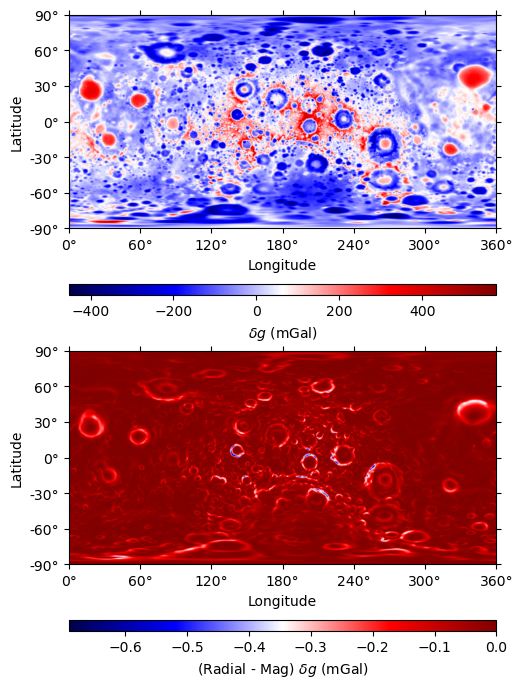

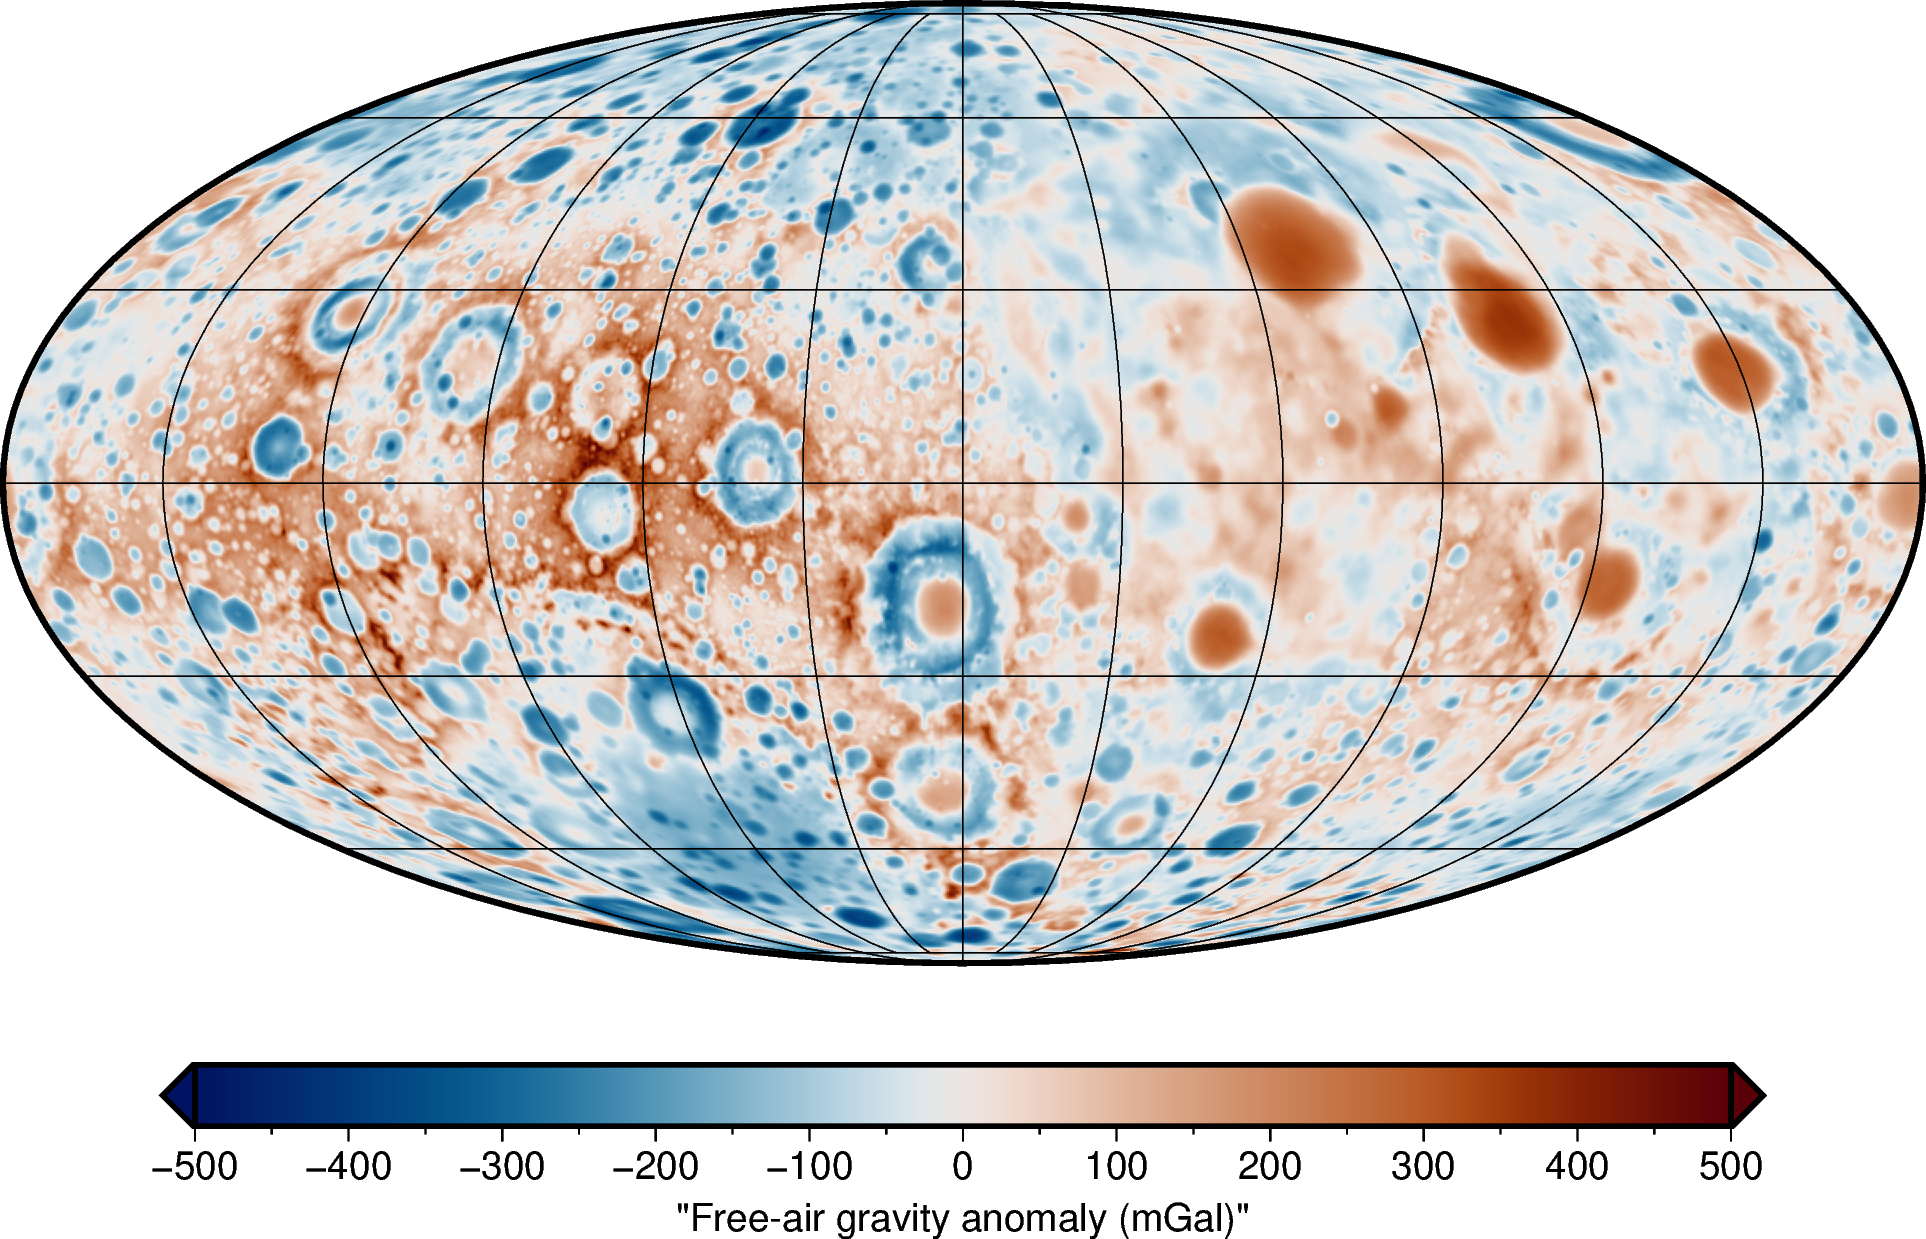

,Min,Max,Mean,Std
Gravity disturbance (mGal),,,,
Gravity disturbance: magnitude,-452.233640,579.066942,-20.859417,107.434532
Gravity disturbance: radial,-452.248697,578.996548,-20.890803,107.432250
Gravity disturbance: dif 1,-0.691161,0.000001,-0.031385,0.048289
Gravity disturbance: dif 2,-0.000000,0.000001,0.000001,0.000000


In [ ]:
# # ! Gravity of Moon
######## * SHGravCoeffs
lmax = 1500
clm_grav_moon = pysh.SHGravCoeffs.from_file('jggrx_1500e_sha.tab', 
                                            lmax=lmax, 
                                            header_units='km', 
                                            errors=True,
                                            omega=cstMoon.angular_velocity.value, 
                                            name='GL1500E (Moon)',
                                            encoding='utf-8')
print('*'*32+'\n' + 'Class SHGravCoeffs: ')
print(clm_grav_moon)
######## * SHGravGrid
r_calc = 1748000.0
#### * Expand
res_grav = 1.0/8 # degree
grd_grav_moon = clm_grav_moon.expand(a=r_calc,
                                     f=0.0,
                                     lmax=int(90/res_grav)-1, 
                                     lmax_calc=450)
print('*'*32+'\n' + 'Class SHGravGrid')
print(grd_grav_moon)
gx = -1.e5 * grd_grav_moon.theta
gy =  1.e5 * grd_grav_moon.phi
gz = -1.e5 * grd_grav_moon.rad
dg =  1.e5 * grd_grav_moon.total
#### * Compute manually the gravity disturbance
gz_gamma =   1.e5 * clm_grav_moon.gm/r_calc**2
gz_omega = - 1.e5 * clm_grav_moon.omega**2 \
    * r_calc * np.cos(np.deg2rad(gz.lats()))**2
g_norm = np.sqrt(gx.data**2 + gy.data**2 + gz.data**2)
dg_rad  = pysh.SHGrid.from_array(gz.data - gz_gamma - gz_omega[:,np.newaxis])
dg_norm = pysh.SHGrid.from_array(g_norm - gz_gamma - gz_omega[:,np.newaxis])
dif_dg1 = dg_rad - dg
dif_dg2 = dg_norm - dg
#### * xarray
xr_grd_grav_moon = grd_grav_moon.to_xarray()
print('*'*32+'\n' + 'Class xarray.Dataset')
print(xr_grd_grav_moon)
#### * Mapping with Matplotlib
fig, axs = plt.subplot_mosaic([['(a)'],['(b)']], 
                               figsize=(6, 8), 
                               height_ratios=[0.45, 0.45])
dg.plot(ax=axs['(a)'], colorbar='bottom', 
        cb_label=r'$\delta g$ (mGal)',
        cmap='seismic', tick_interval=[60, 30])
dif_dg1.plot(ax=axs['(b)'], colorbar='bottom', 
             cb_label=r'(Radial - Mag) $\delta g$ (mGal)',
             cmap='seismic', tick_interval=[60, 30])
plt.savefig('moon_dg_rad_mag', dpi=300, bbox_inches='tight')
plt.show()
#### * Mapping with PyGMT
fig = pygmt.Figure()
dg.plotgmt(fig=fig,
           projection='mollweide',
           central_longitude=-90.,
           grid=[30, 30],
           tick_interval=None,
           cmap='vik',
           cmap_limits=[-500, 500],
           colorbar='bottom',
           cb_triangles='both',
           cb_label='Free-air gravity anomaly (mGal)',
           cb_tick_interval=100,
           cb_minor_tick_interval=50)
fig.show(width=800)
fig.savefig('moon_dg.png', dpi=300)
######## * Stats
Gs = {'Gravity disturbance: magnitude': dg.to_array(), 
      'Gravity disturbance: radial': dg_rad.to_array(),
      'Gravity disturbance: dif 1': dif_dg1.to_array(),
      'Gravity disturbance: dif 2': dif_dg2.to_array()}
stats = {
    name: {'Min': arr.min(), 'Max': arr.max(),
           'Mean': arr.mean(), 'Std': arr.std()}
    for name, arr in Gs.items()}
df = pd.DataFrame(stats).T
df.index.name = 'Gravity disturbance (mGal)'
df.style.format("{:.6f}").set_properties(**{'text-align': 'center'})

In [ ]:
# # ! Shape/Topo of Moon
######## * Shape
r_ref = 1738000.0
res_topo = np.array([1.0/8, 1.0/16, 1.0/32, 1.0/64]) # degree
LMAX_shp = np.asanyarray(90/res_topo-1, dtype=int)
print("Topographic Statistics of the Moon at Increasing Spherical Harmonic Resolutions")
print("(Values in km relative to reference radius = 1738 km)")
print('    lmax | time_sec |      min |      max |     mean |      std')
print('-'*64)
topo_old = pysh.SHGrid.from_zeros(lmax=5759)
for i, lmax_shp in enumerate(LMAX_shp):
    t0 = time.time()
    clm_shp_moon = pysh.SHCoeffs.from_file(f'Moon_shape_{lmax_shp}.sh', 
                                           lmax=lmax_shp, 
                                           name='LOLA_shape (Moon)',
                                           units='m', format='bshc')
    grd_shp_moon = clm_shp_moon.expand(lmax=5759, 
                                       lmax_calc=lmax_shp)
    tc = time.time() - t0
    topo_new = (grd_shp_moon - r_ref) / 1.e3
    min_val  = np.min(topo_new.data)
    max_val  = np.max(topo_new.data)
    mean_val = np.mean(topo_new.data)
    std_val  = np.std(topo_new.data)
    print(f"{lmax_shp:8d} | {tc:8.3f} | {min_val:8.4f} | {max_val:8.4f} | {mean_val:8.4f} | {std_val:8.4f}")
    if i>=1:
        dif_topo = topo_new - topo_old
        min_val  = np.min(dif_topo.data)
        max_val  = np.max(dif_topo.data)
        mean_val = np.mean(dif_topo.data)
        std_val  = np.std(dif_topo.data)      
        print(f"nmax: ({LMAX_shp[i]:4d} - {LMAX_shp[i-1]:4d}) | {min_val:8.4f} | {max_val:8.4f} | {mean_val:8.4f} | {std_val:8.4f}")
    topo_old = topo_new.copy()         

Topographic Statistics of the Moon at Increasing Spherical Harmonic Resolutions
(Values in km relative to reference radius = 1738 km)
    lmax | time_sec |      min |      max |     mean |      std
----------------------------------------------------------------
     719 |    0.313 |  -9.3316 |   9.9854 |  -1.1195 |   2.2011
    1439 |    0.415 | -10.1074 |  10.1626 |  -1.1194 |   2.2065
nmax: (1439 -  719) |  -1.8987 |   1.3480 |   0.0001 |   0.1516
    2879 |    0.852 |  -9.7601 |  10.1707 |  -1.1194 |   2.2076
nmax: (2879 - 1439) |  -0.9059 |   0.6720 |   0.0000 |   0.0703
    5759 |    2.831 |  -9.7050 |  10.1700 |  -1.1194 |   2.2078
nmax: (5759 - 2879) |  -0.5727 |   0.7677 |  -0.0000 |   0.0252


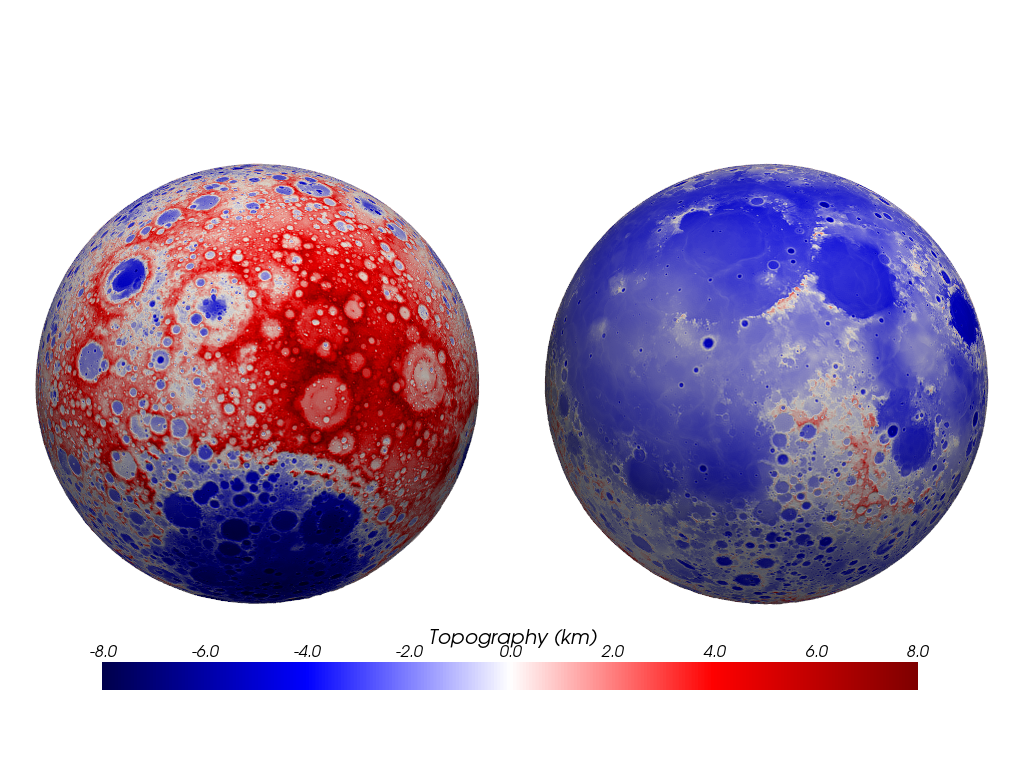

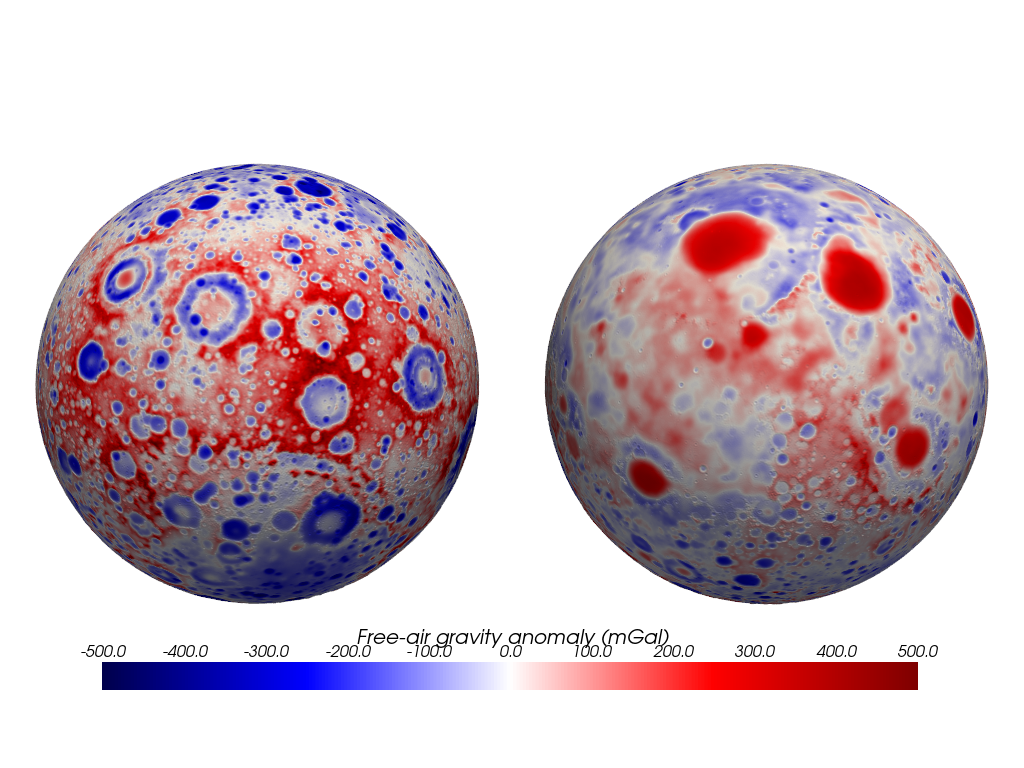

In [ ]:
# # ! PyVista 3D Visualization
#### * Shape/Topo
grd_shp_moon = clm_shp_moon.expand(lmax=719, 
                                   lmax_calc=719)
mesh_shp_moon = pv.Sphere(radius=1.0, center=(0.0, 0.0, 0.0),
                          theta_resolution=grd_shp_moon.nlon-1,
                          phi_resolution=grd_shp_moon.nlat)
[LON, LAT] = np.meshgrid(grd_shp_moon.lons(), grd_shp_moon.lats())
R_SHP = grd_shp_moon.data
X = R_SHP * np.cos(np.deg2rad(LAT)) * np.cos(np.deg2rad(LON))
Y = R_SHP * np.cos(np.deg2rad(LAT)) * np.sin(np.deg2rad(LON))
Z = R_SHP * np.sin(np.deg2rad(LAT))
# north pole, south pole, and regular points
pts_x = np.hstack([X[0,0], X[-1,0], X[1:-1,:-1].flatten(order='F')]) 
pts_y = np.hstack([Y[0,0], Y[-1,0], Y[1:-1,:-1].flatten(order='F')])
pts_z = np.hstack([Z[0,0], Z[-1,0], Z[1:-1,:-1].flatten(order='F')])
Verts = np.column_stack((pts_x, pts_y, pts_z))
mesh_shp_moon.points = Verts
Faces = mesh_shp_moon.regular_faces
pts_r = np.sqrt(pts_x**2 + pts_y**2 + pts_z**2)
pts_topo = (pts_r - r_ref) / 1.e3
mesh_shp_moon['Topography'] = pts_topo
#### * Gravity disturbance
pts_dg = np.hstack([dg.data[0,0], dg.data[-1,0],
                   dg.data[1:-1,:-1].flatten(order='F')]) 
mesh_shp_moon['FreeAirGrav'] = pts_dg

Titles = ['Topography (km)', 'Free-air gravity anomaly (mGal)']
Scalars = ['Topography', 'FreeAirGrav']
Clims = [[-8, 8], [-500, 500]]
N_lab = [9, 11]
for title, scalar, clim, n_lab in zip(Titles, Scalars, Clims, N_lab):
    sargs = dict(
        title=title,
        title_font_size=20,
        label_font_size=16,
        n_labels=n_lab,
        italic=True,
        fmt='%.1f',
        font_family='arial',
        width=0.8,
        height=0.1,
        position_x=0.1,
        position_y=0.1,
        vertical=False)
    pl = pv.Plotter()
    mesh_front = mesh_shp_moon.translate([0, 2.e6, 0])
    mesh_back = mesh_shp_moon.rotate_z(180).translate([0, -2.e6, 0])
    pl.add_mesh(
        mesh_front,
        cmap='seismic',
        clim=clim,
        scalars=scalar,
        show_scalar_bar=False)
    pl.add_mesh(
        mesh_back,
        cmap='seismic',
        clim=clim,
        scalars=scalar,
        show_scalar_bar=False)
    pl.add_scalar_bar(**sargs)
    pl.view_yz()
    pl.camera.Zoom(1.5)
    pl.show()
    pl.screenshot(f"Moon_{scalar}_3D.png")